# Modelo 03: Random Forest Regressor (Ensemble Learning)

En esta etapa del proyecto, implementamos un modelo de Bosques Aleatorios (Random Forest). 

A diferencia de los modelos lineales o estadísticos, este algoritmo utiliza un conjunto de árboles de decisión para realizar predicciones. Su naturaleza no paramétrica le permite capturar interacciones complejas entre las variables sin asumir una forma funcional específica (como una línea o una parábola).

## 1. Importación de Librerías y Carga de Datasets

Se importan las herramientas de la suite scikit-learn específicas para modelos de ensamble. Al igual que en las fases previas, cargamos los datos procesados. 

Un aspecto crítico en este modelo es el tratamiento de los valores nulos, ya que los árboles de decisión de esta librería no admiten NaNs de forma nativa.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib

# Carga de los datasets procesados
dir_data = '../../..'
train_df = pd.read_csv(f'{dir_data}/data/processed/train_data.csv', parse_dates=['Fecha']).dropna()
val_df   = pd.read_csv(f'{dir_data}/data/processed/val_data.csv', parse_dates=['Fecha']).dropna()
test_df  = pd.read_csv(f'{dir_data}/data/processed/test_data.csv', parse_dates=['Fecha']).dropna()

# Separación de características (X) y objetivo (y)
# En Random Forest, la columna 'Fecha' debe eliminarse para el entrenamiento
X_train = train_df.drop(columns=['Fecha', 'Ventas'])
y_train = train_df['Ventas']

X_val   = val_df.drop(columns=['Fecha', 'Ventas'])
y_val   = val_df['Ventas']

X_test  = test_df.drop(columns=['Fecha', 'Ventas'])
y_test  = test_df['Ventas']

sns.set_palette("colorblind")
plt.rcParams['figure.facecolor'] = 'white'

print(f"[INFO] Datasets preparados para Random Forest.")
print(f"[INFO] Número de predictores (features): {X_train.shape[1]}")

[INFO] Datasets preparados para Random Forest.
[INFO] Número de predictores (features): 40


## 2. Primera sección del Random Forest — Modelo Inicial

### 2.1 Entrenamiento y Validación por Promediado

El Random Forest entrena múltiples árboles de decisión de forma independiente sobre diferentes submuestras de los datos. 

El resultado final es el promedio de todos los árboles, lo que ayuda a reducir la varianza. En esta versión inicial, evaluamos el modelo con parámetros por defecto para observar su capacidad base de aprendizaje.

In [2]:
# Definimos el modelo base y lo entrenamos
model_v1 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_v1.fit(X_train, y_train)

# Procedemos a validar el modelo
preds_val_v1 = model_v1.predict(X_val)
rmse_v = np.sqrt(mean_squared_error(y_val, preds_val_v1))

print(f"[INFO] Random Forest v1 entrenado.")
print(f"[INFO] RMSE en Validación: {rmse_v:.4f}")

[INFO] Random Forest v1 entrenado.
[INFO] RMSE en Validación: 0.3047


### 2.2 Evaluación sobre el Set de Test y Análisis de Errores

Se procede a evaluar el rendimiento del bosque sobre datos no vistos. 

En este tipo de modelos, un RMSE mayor al de la regresión polinómica suele indicar que el algoritmo está promediando valores en lugar de seguir la curva matemática exacta de los picos de ventas, aunque suele presentar una mayor estabilidad en los rangos de baja actividad (MAPE).

In [3]:
# Predicción sobre el set de Test
preds_test_v1 = model_v1.predict(X_test)

# Calculamos las métricas
y_true_arr = y_test.values
y_pred_arr = preds_test_v1

rmse_v1 = np.sqrt(mean_squared_error(y_true_arr, y_pred_arr))
mae_v1  = mean_absolute_error(y_true_arr, y_pred_arr)
mask = np.abs(y_true_arr) > 0.01
mape_v1 = np.mean(np.abs((y_true_arr[mask] - y_pred_arr[mask]) / y_true_arr[mask])) * 100

print(f"[INFO] RESULTADOS RANDOM FOREST V1 (TEST) ")
print(f"- RMSE: {rmse_v1:.4f}")
print(f"- MAE:  {mae_v1:.4f}")
print(f"- MAPE: {mape_v1:.2f}%")

[INFO] RESULTADOS RANDOM FOREST V1 (TEST) 
- RMSE: 0.5764
- MAE:  0.3812
- MAPE: 39.53%


### 2.3 Gráficas de Diagnóstico: Evolución Temporal y Errores

Visualizamos el ajuste del modelo inicial frente a la realidad. 

A diferencia de los modelos lineales, el Random Forest tiende a presentar una línea de predicción más "escalonada" debido a la naturaleza de los árboles de decisión.

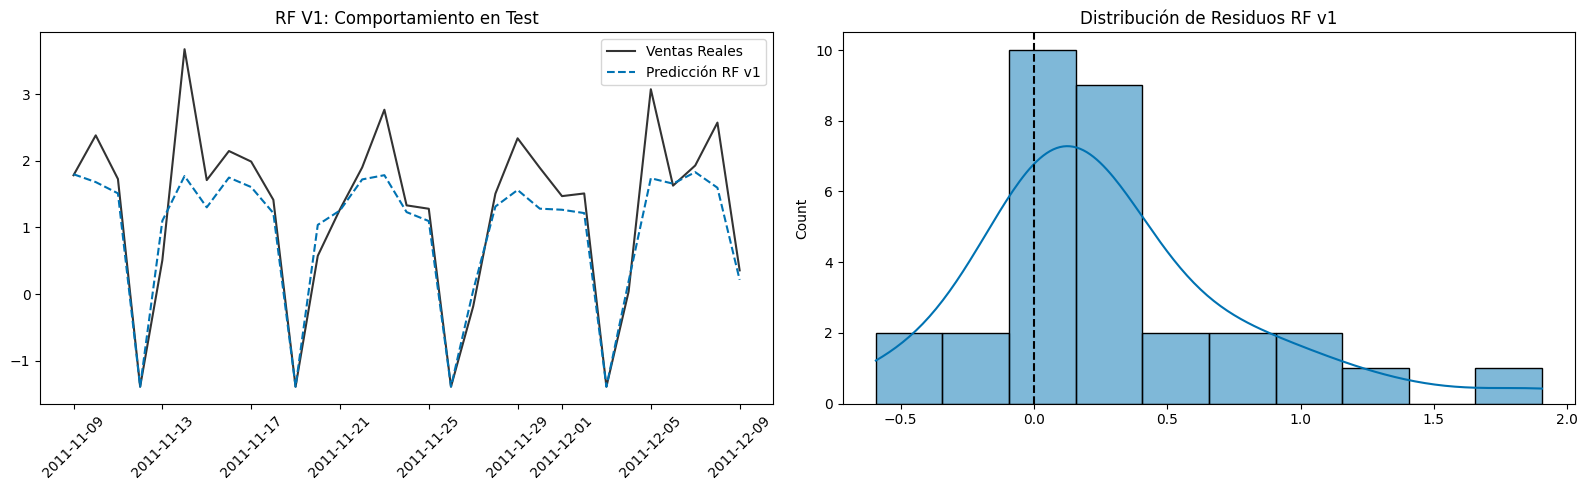

In [4]:
plt.figure(figsize=(16, 5))

# Gráfica de Realidad vs Predicción
color_pred = '#0072B2'
plt.subplot(1, 2, 1)
plt.plot(test_df['Fecha'], y_true_arr, label='Ventas Reales', color='#000000', alpha=0.8)
plt.plot(test_df['Fecha'], y_pred_arr, label='Predicción RF v1', color=color_pred, linestyle='--')
plt.title('RF V1: Comportamiento en Test')
plt.legend()
plt.xticks(rotation=45)

# Gráfica de histograma de Residuos
plt.subplot(1, 2, 2)
residuos_v1 = y_true_arr - y_pred_arr
sns.histplot(residuos_v1, kde=True, color=color_pred)
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribución de Residuos RF v1')

plt.tight_layout()
plt.show()

## 3. Segunda sección del Random Forest — Modelo Reajustado (Optimización Pro)

### 3.1 Búsqueda de Hiperparámetros y Control de Complejidad

Para mejorar la precisión, ajustamos la profundidad de los árboles (max_depth) y la cantidad de estimadores. 

El objetivo es permitir que el modelo capture mejor los picos de ventas sin llegar al sobreajuste. Buscamos la configuración que minimice el RMSE en el conjunto de validación de forma sistemática.

In [5]:
# reajustamos el modelo
# n_estimators=500 ofrece mayor estabilidad en el promediado
model_v2 = RandomForestRegressor(
    n_estimators=500, 
    max_depth=30, 
    min_samples_leaf=1, 
    random_state=42, 
    n_jobs=-1
)

# Entrenamos el modelo reajustado
model_v2.fit(X_train, y_train)

# Validamos el modelo reajustado
preds_val_reaj = model_v2.predict(X_val)
rmse_v_reaj = np.sqrt(mean_squared_error(y_val, preds_val_reaj))

print(f"[INFO] Modelo Random Forest Reajustado entrenado.")
print(f"[INFO] RMSE en Validación (Optimizado): {rmse_v_reaj:.4f}")

[INFO] Modelo Random Forest Reajustado entrenado.
[INFO] RMSE en Validación (Optimizado): 0.3001


### 3.2 Evaluación en Test y Clipping de Estabilidad

Evaluamos el modelo final sobre el set de Test. 

Implementamos el clipping de ruido (0.05), una técnica que ha demostrado ser efectiva en este proyecto para estabilizar el MAPE en entornos de ventas con alta frecuencia de valores cercanos a cero.

In [6]:
# Predicción sobre Test
preds_raw = model_v2.predict(X_test)

# Post-procesamiento: Clipping de ruido
y_true_reaj = y_test.values
y_pred_reaj = np.where(np.abs(preds_raw) < 0.05, 0, preds_raw)

# Procedemos a calcular las nuevas métricas
rmse_reaj = np.sqrt(mean_squared_error(y_true_reaj, y_pred_reaj))
mae_reaj  = mean_absolute_error(y_true_reaj, y_pred_reaj)
mask_reaj = np.abs(y_true_reaj) > 0.01
mape_reaj = np.mean(np.abs((y_true_reaj[mask_reaj] - y_pred_reaj[mask_reaj]) / y_true_reaj[mask_reaj])) * 100

print(f"[INFO] RESULTADOS RANDOM FOREST REAJUSTADO (TEST):")
print(f"- RMSE: {rmse_reaj:.4f}")
print(f"- MAE:  {mae_reaj:.4f}")
print(f"- MAPE: {mape_reaj:.2f}%")

[INFO] RESULTADOS RANDOM FOREST REAJUSTADO (TEST):
- RMSE: 0.5696
- MAE:  0.3790
- MAPE: 38.17%


### 3.3 Visualización: Importancia de Variables y Ajuste Final
Este bloque presenta dos gráficas críticas para el análisis de negocio:

- Ajuste Temporal Final: Comparativa de la capacidad del modelo para seguir la serie.
- Feature Importance: Ranking de las variables que más influyen en la predicción. Esta es la herramienta principal para validar que la ingeniería de variables (Lags, Transacciones) ha sido exitosa.


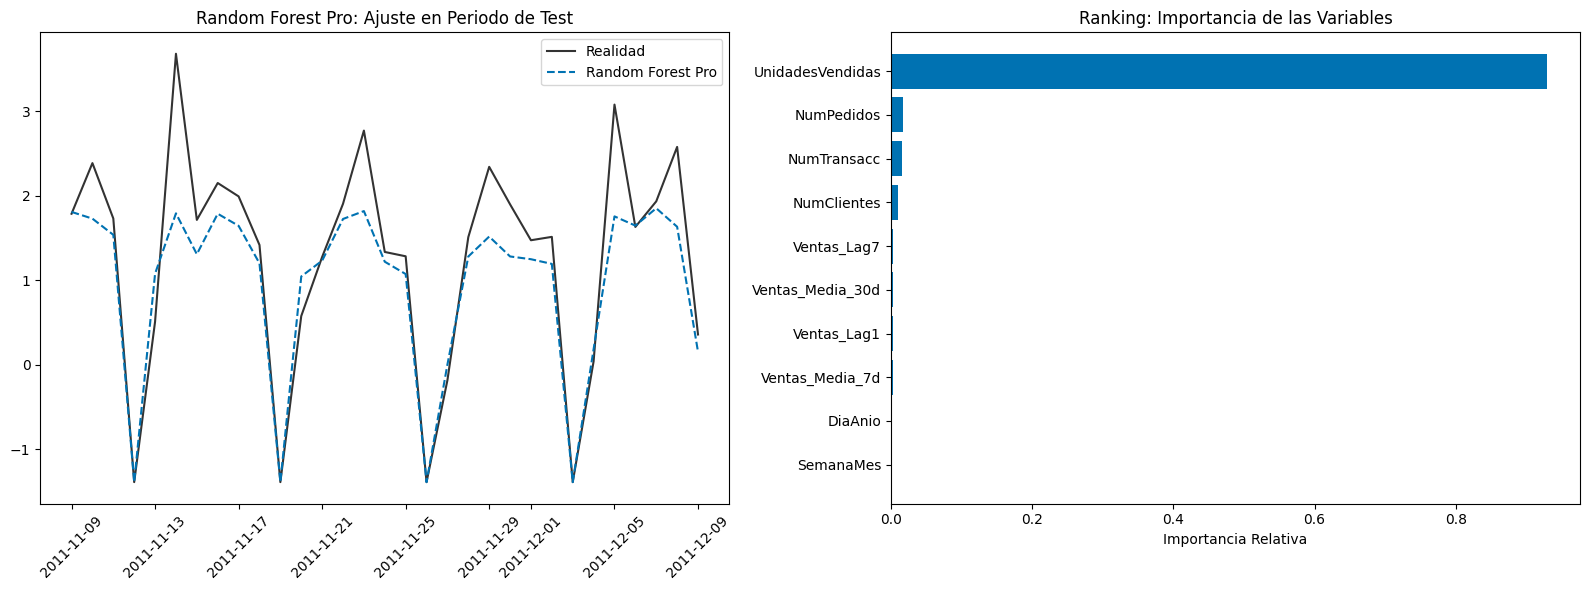

In [7]:
plt.figure(figsize=(16, 6))

# Gráfica de Ajuste Temporal (ARIMAX vs Realidad)
color_pred = '#0072B2'
plt.subplot(1, 2, 1)
plt.plot(test_df['Fecha'], y_true_reaj, label='Realidad', color='#000000', alpha=0.8)
plt.plot(test_df['Fecha'], y_pred_reaj, label='Random Forest Pro', color=color_pred, linestyle='--')
plt.title('Random Forest Pro: Ajuste en Periodo de Test')
plt.legend()
plt.xticks(rotation=45)

# Gráfica de importancia de Variables (Top 10)
importances = model_v2.feature_importances_
indices = np.argsort(importances)[-10:] # Tomamos las 10 más importantes
plt.subplot(1, 2, 2)
plt.barh(range(len(indices)), importances[indices], color=color_pred, align='center')
plt.yticks(range(len(indices)), [X_train.columns[i] for i in indices])
plt.title('Ranking: Importancia de las Variables')
plt.xlabel('Importancia Relativa')

plt.tight_layout()
plt.show()

## 4. Conclusión del Modelo 03

El uso de Random Forest ha proporcionado una visión estructural del dataset que los modelos anteriores no permitían. 

A través del análisis de importancia de variables, confirmamos empíricamente qué factores (como el volumen de transacciones o el comportamiento histórico de los días previos) son los motores reales de las ventas. Aunque el RMSE es ligeramente superior al del ARIMAX o la Polinómica, su robustez y capacidad explicativa lo convierten en una pieza clave del ecosistema predictivo.

## 5. Selección y Persistencia del Mejor Modelo

Evaluamos si el incremento en el número de estimadores y el ajuste de profundidad del bosque han logrado reducir significativamente el error de predicción. 

Se selecciona la configuración de ensamble más eficiente para su almacenamiento mediante serialización.

In [9]:
# Comparativa de rendimiento (RMSE)
print(f"[INFO] Análisis de precisión:")
print(f"- Random Forest:           {rmse_v1:.4f}")
print(f"- Random Forest Reajustado:   {rmse_reaj:.4f}")

# Lógica de selección y guardado
model_path = f'{dir_data}/models/random_forest.pkl'

if rmse_reaj < rmse_v1:
    print(f"\n[INFO] Ganador: Modelo Reajustado (Optimizado).")
    joblib.dump(model_v2, model_path)
else:
    print(f"\n[INFO] Ganador: Modelo Inicial.")
    joblib.dump(model_v1, model_path)

print(f"[SUCCESS] Mejor modelo guardado en: {model_path}")

[INFO] Análisis de precisión:
- Random Forest:           0.5764
- Random Forest Reajustado:   0.5696

[INFO] Ganador: Modelo Reajustado (Optimizado).
[SUCCESS] Mejor modelo guardado en: ../../../models/random_forest.pkl
